# Predicting Retail Supply Stress with Machine Learning

## An end-to-end M5 Forecasting case study

This project develops an early-warning classifier for unusually high retail demand using the M5 Forecasting dataset. The goal is not to forecast exact unit sales. Instead, the model ranks item-store observations by the likelihood of entering a high-demand state that may create inventory pressure.

### Business question

> Can recent demand behavior, calendar context, pricing, and store location help identify potential supply-stress events before they occur?

### What this notebook demonstrates

- Reproducible loading and validation of raw data
- Long-format preprocessing and target construction
- Leakage-safe temporal feature engineering
- Chronological model validation
- Class-balanced XGBoost training
- Evaluation designed for an imbalanced target
- Threshold analysis tied to operational trade-offs
- SHAP-based model interpretation
- Reusable model persistence and inference

> **Target limitation:** M5 does not include verified inventory or stockout labels. The project therefore uses an item-relative high-demand event as a transparent proxy for potential supply stress.


## 1. Project setup

Reusable business logic lives in the `src/` package. The notebook is responsible for orchestration, analysis, visualization, and interpretation—not for duplicating production code.

The expected repository structure is:

```text
sc-shortage-eval/
├── data/raw/
├── models/
├── notebooks/
├── reports/figures/
└── src/
```


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.metrics import classification_report

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data" / "raw"
MODELS_DIR = REPO_ROOT / "models"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from src.evaluate import (
    find_best_f1_threshold,
    plot_confusion_matrix,
    plot_precision_recall,
)
from src.features import prepare_model_input
from src.load_data import load_m5_data
from src.predict import predict_supply_stress
from src.preprocess import build_analytical_table
from src.train import (
    chronological_split,
    save_model_artifacts,
    train_final_xgboost,
)

pd.set_option("display.max_columns", 50)


c:\Users\tarma\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the M5 source tables

The project uses three source files:

- **Sales:** daily unit sales by item and store
- **Calendar:** dates, events, SNAP indicators, and M5 week identifiers
- **Prices:** weekly item-store selling prices

The loader validates that all required files exist before analysis begins.


In [2]:
raw = load_m5_data(DATA_DIR)

source_shapes = pd.DataFrame(
    {
        "table": ["sales", "calendar", "prices"],
        "rows": [
            len(raw.sales),
            len(raw.calendar),
            len(raw.prices),
        ],
        "columns": [
            raw.sales.shape[1],
            raw.calendar.shape[1],
            raw.prices.shape[1],
        ],
    }
)

source_shapes


,table,rows,columns
0,sales,30490,1919
1,calendar,1969,14
2,prices,6841121,4


In [3]:
raw.sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,...,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


## 3. Build the analytical table

The preprocessing workflow:

1. Restricts development to the first 100 unique items so the project can run locally.
2. Reshapes daily sales from wide to long format.
3. Creates an item-relative 90th-percentile stress threshold.
4. Merges calendar and price context.
5. Sorts observations chronologically by item and store.

This produces one row per item-store-day observation.


In [4]:
analytical = build_analytical_table(
    raw.sales,
    raw.calendar,
    raw.prices,
    max_items=100,
    stress_quantile=0.90,
)

print(f"Analytical rows: {len(analytical):,}")
print(f"Analytical columns: {analytical.shape[1]}")

analytical.head()


Analytical rows: 1,913,000
Analytical columns: 26


,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,day_num,stress_threshold,stress_event,d,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,1,1.0,0,d_1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2,1.0,0,d_2,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,3,1.0,0,d_3,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,4,1.0,0,d_4,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0,NaN
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,5,1.0,0,d_5,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1,NaN


### Target definition

For each item, observations above its own historical 90th-percentile sales level are labeled `stress_event = 1`.

This relative definition avoids applying the same sales cutoff to products with very different demand scales. It should still be interpreted as a **high-demand proxy**, not proof of a stockout.


In [5]:
target_summary = (
    analytical["stress_event"]
    .value_counts()
    .rename_axis("stress_event")
    .to_frame("count")
)

target_summary["proportion"] = (
    target_summary["count"] / target_summary["count"].sum()
)

target_summary


,count,proportion
stress_event,,
0,1796728,0.93922
1,116272,0.06078


### Exploratory geographic signal

Stress prevalence varies materially by store. This supports including geographic indicators, while also warning that store identity may capture multiple underlying operational factors such as customer mix, replenishment policy, and local demand patterns.


In [6]:
store_stress = (
    analytical
    .groupby("store_id", as_index=False)["stress_event"]
    .mean()
    .sort_values("stress_event", ascending=False)
    .rename(columns={"stress_event": "stress_rate"})
)

store_stress


,store_id,stress_rate
2,CA_3,0.106503
0,CA_1,0.089712
5,TX_2,0.074250
7,WI_1,0.064794
1,CA_2,0.058761
6,TX_3,0.057888
3,CA_4,0.046315
9,WI_3,0.042943
4,TX_1,0.036205
8,WI_2,0.030429


## 4. Shared feature engineering

The same function is used during training and inference, reducing the risk of **training-serving skew**.

### Engineered signals

- `sales_lag_1`: sales one day earlier
- `sales_lag_7`: sales seven days earlier
- `rolling_mean_7`: average sales over the previous seven completed days
- `rolling_std_7`: short-term demand volatility
- weekend and event indicators
- SNAP eligibility indicators
- current selling price and one-period price movement
- one-hot encoded state and store indicators

All lag and rolling features are grouped by both `item_id` and `store_id`. `shift(1)` prevents the current day's sales from leaking into the current prediction.


In [7]:
feature_data, X, model_features = prepare_model_input(analytical)
y = feature_data["stress_event"]

feature_summary = pd.Series(
    {
        "model_rows": len(X),
        "feature_count": X.shape[1],
        "positive_events": int(y.sum()),
        "positive_rate": float(y.mean()),
        "missing_feature_values": int(X.isna().sum().sum()),
    }
)

feature_summary


model_rows                1.590092e+06
feature_count             2.200000e+01
positive_events           1.158800e+05
positive_rate             7.287629e-02
missing_feature_values    0.000000e+00
dtype: float64

In [8]:
pd.DataFrame({"feature": model_features})

,feature
0,sales_lag_1
1,sales_lag_7
2,rolling_mean_7
3,rolling_std_7
4,is_event_day
5,is_weekend
6,snap_CA
7,snap_TX
8,snap_WI
9,sell_price


## 5. Chronological validation

A random split can mix earlier and later observations, producing an optimistic estimate for a future-facing use case. The final model is therefore trained on the earliest 80% of model-ready rows and evaluated on the latest 20%.

This setup asks the operationally relevant question:

> How well does the model generalize to a later period it did not see during training?


In [9]:
X_train, X_test, y_train, y_test = chronological_split(
    X,
    y,
    train_fraction=0.80,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "positive_rate": [y_train.mean(), y_test.mean()],
    }
)

split_summary


,split,rows,positive_rate
0,train,1272073,0.072387
1,test,318019,0.074835


## 6. Train the final class-balanced XGBoost model

XGBoost was selected after comparison with Random Forest because it achieved the strongest minority-class recall and F1 under chronological validation.

Class imbalance is handled using `scale_pos_weight`, calculated only from the training period. This makes missed stress events more costly during optimization without using information from the test period.


In [10]:
final_model = train_final_xgboost(
    X_train,
    y_train,
)

test_probabilities = final_model.predict_proba(X_test)[:, 1]
default_predictions = (test_probabilities >= 0.50).astype(int)

print(
    classification_report(
        y_test,
        default_predictions,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

           0       0.95      0.70      0.81    294220
           1       0.13      0.55      0.21     23799

    accuracy                           0.69    318019
   macro avg       0.54      0.63      0.51    318019
weighted avg       0.89      0.69      0.76    318019



### Default operating point: threshold 0.50

The default threshold intentionally favors **recall**. For an early-warning system, missing a genuine risk may be more costly than investigating an additional alert.

The expected trade-off is:

- more stress events detected;
- more false-positive alerts;
- lower overall accuracy than a majority-class model;
- substantially better operational usefulness than a model that predicts almost no stress events.


## 7. Evaluate the model as an early-warning system

Accuracy alone is inappropriate because the target is imbalanced. The following views are more informative:

- **Confusion matrix:** actual alert outcomes
- **Precision–Recall curve:** ranking quality across thresholds
- **Average Precision:** summary of the Precision–Recall curve
- **Threshold analysis:** operational control over alert volume and missed events


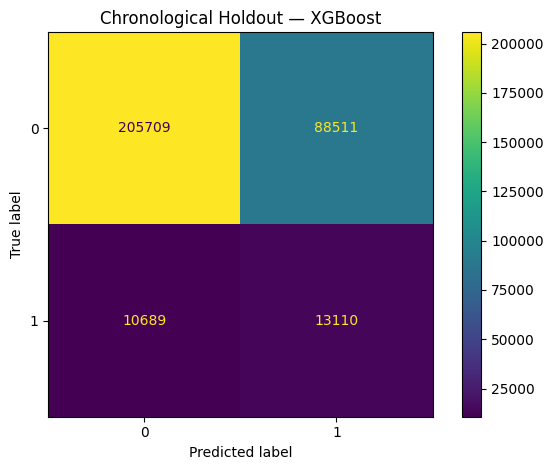

In [11]:
plot_confusion_matrix(
    final_model,
    X_test,
    y_test,
    title="Chronological Holdout — XGBoost",
    output_path=FIGURES_DIR / "confusion_matrix.png",
)


**Interpretation:** The confusion matrix should be read as an operational workload. True positives are successfully detected stress events, false negatives are missed risks, and false positives represent investigations that do not ultimately correspond to the proxy event.


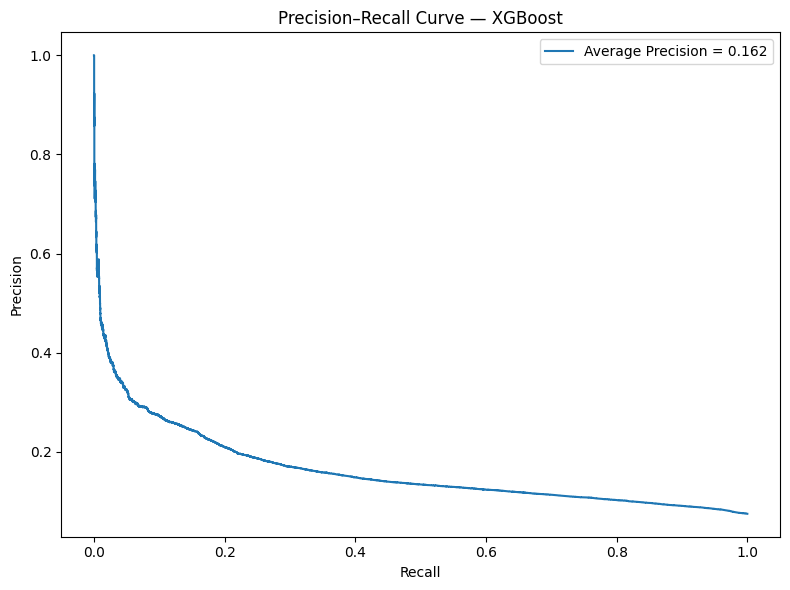

In [12]:
plot_precision_recall(
    y_test,
    test_probabilities,
    title="Precision–Recall Curve — XGBoost",
    output_path=FIGURES_DIR / "precision_recall_curve.png",
)


**Interpretation:** Precision declines as recall rises. The model is therefore better suited to **risk ranking and early warning** than fully automated decisions. A planning team could review the highest-risk item-store observations first rather than treating every alert as equally urgent.


## 8. Decision-threshold analysis

The model produces probabilities; the threshold converts those probabilities into alerts.

- A **lower threshold** catches more genuine stress events but creates more false alarms.
- A **higher threshold** generates fewer, more selective alerts but misses more events.

The F1-maximizing threshold is useful as an alternative operating point. In a production study it should be selected on a separate validation period—not on the final test set.


In [13]:
best_threshold = find_best_f1_threshold(
    y_test,
    test_probabilities,
)

pd.Series(
    {
        "threshold": best_threshold.threshold,
        "precision": best_threshold.precision,
        "recall": best_threshold.recall,
        "f1": best_threshold.f1,
    }
)


threshold    0.627710
precision    0.157788
recall       0.356065
f1           0.218673
dtype: float64

In [14]:
alternative_predictions = (
    test_probabilities >= best_threshold.threshold
).astype(int)

print(
    classification_report(
        y_test,
        alternative_predictions,
        zero_division=0,
    )
)


              precision    recall  f1-score   support

           0       0.94      0.85      0.89    294220
           1       0.16      0.36      0.22     23799

    accuracy                           0.81    318019
   macro avg       0.55      0.60      0.56    318019
weighted avg       0.88      0.81      0.84    318019



### Threshold recommendation

For this project, **0.50 remains the preferred early-warning threshold** because recall is the principal business objective.

The higher F1 threshold is retained as an alternative for environments with limited investigation capacity or severe alert fatigue.


## 9. Explain the final model with SHAP

Global importance says which variables matter. SHAP adds direction: it shows whether a particular feature value pushes an observation toward or away from the stress class.

A small test sample is used because local SHAP computation can be expensive on a laptop.


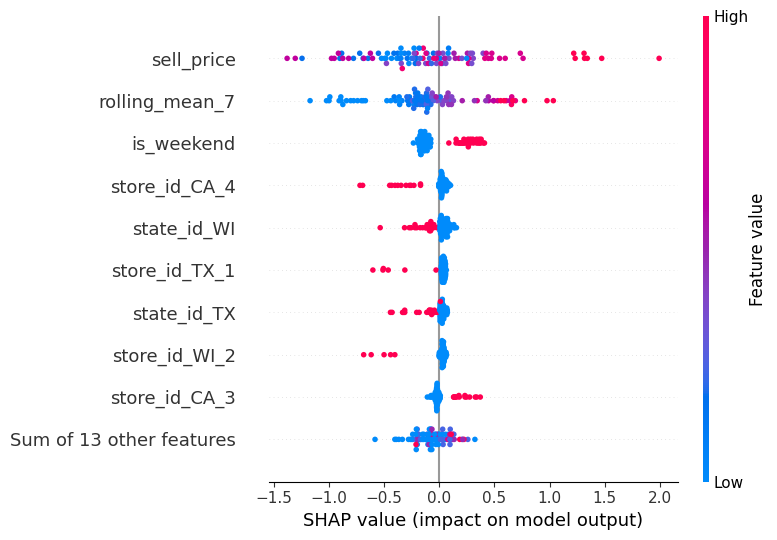

In [15]:
shap_sample = X_test.sample(
    min(100, len(X_test)),
    random_state=42,
)

explainer = shap.Explainer(final_model)
shap_values = explainer(shap_sample)

# SHAP versions differ in how binary-class outputs are represented.
if len(shap_values.shape) == 3:
    stress_shap_values = shap_values[:, :, 1]
else:
    stress_shap_values = shap_values

import matplotlib.pyplot as plt

shap.plots.beeswarm(
    stress_shap_values,
    max_display=10,
    show=False,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


### How to read the SHAP chart

- Features are ordered by overall contribution.
- Points to the **right** increase predicted stress risk.
- Points to the **left** decrease predicted stress risk.
- Color represents the underlying feature value.

The most useful outcome is not merely identifying important variables, but checking whether learned relationships are operationally plausible and consistent with earlier exploratory findings.


## 10. Persist the final model and metadata

The model artifact is saved together with:

- the exact feature schema;
- the default early-warning threshold;
- the alternative threshold found during analysis.

Saving the schema is essential because inference data must use the same columns and ordering as training data.


In [16]:
save_model_artifacts(
    final_model,
    model_features,
    MODELS_DIR,
    default_threshold=0.50,
    alternative_threshold=best_threshold.threshold,
)

sorted(path.name for path in MODELS_DIR.iterdir())


['final_xgboost_supply_stress.pkl', 'model_config.json', 'model_features.json']

## 11. Production-style inference demonstration

The inference function:

1. loads the persisted model and metadata;
2. recreates the same features used during training;
3. aligns the input to the saved feature schema;
4. calculates stress probabilities;
5. returns a readable risk label.

Recent history is required because lag and rolling features cannot be created from an isolated observation.


In [17]:
demo_history = (
    analytical
    .sort_values(["item_id", "store_id", "day_num"])
    .groupby(["item_id", "store_id"])
    .tail(30)
    .copy()
)

demo_results = predict_supply_stress(
    demo_history,
    models_dir=MODELS_DIR,
    threshold=0.50,
)

(
    demo_results[
        [
            "item_id",
            "store_id",
            "day_num",
            "stress_probability",
            "risk_label",
        ]
    ]
    .sort_values("stress_probability", ascending=False)
    .head(20)
)


,item_id,store_id,day_num,stress_probability,risk_label
63113,HOBBIES_1_004,CA_3,1898,0.940592,Stress Risk
866588,HOBBIES_1_046,CA_3,1913,0.935281,Stress Risk
862762,HOBBIES_1_046,CA_1,1913,0.934165,Stress Risk
864668,HOBBIES_1_046,CA_2,1906,0.932888,Stress Risk
862761,HOBBIES_1_046,CA_1,1912,0.931975,Stress Risk
866587,HOBBIES_1_046,CA_3,1912,0.930852,Stress Risk
432337,HOBBIES_1_023,TX_2,1913,0.930615,Stress Risk
862748,HOBBIES_1_046,CA_1,1899,0.930554,Stress Risk
63128,HOBBIES_1_004,CA_3,1913,0.929623,Stress Risk
63114,HOBBIES_1_004,CA_3,1899,0.929181,Stress Risk


## 12. Business conclusions

### What the project demonstrates

- Recent sales level and volatility contain useful warning signal.
- Calendar, price, and location context add operational information.
- Class balancing is necessary; unbalanced boosted trees can achieve high accuracy while detecting almost no stress events.
- Chronological validation produces a more credible future-period estimate.
- Threshold choice changes business behavior without retraining the model.
- Shared feature code supports consistent training and inference.

### Recommended use

Deploy the model as a **prioritized review queue**:

1. score current item-store observations;
2. rank them by predicted probability;
3. investigate the highest-risk cases using inventory, replenishment, and supplier context;
4. record outcomes to improve the target and model over time.

### Limitations

- The target is a high-demand proxy, not a verified shortage label.
- The local development run uses 100 items rather than the full M5 catalog.
- Inventory levels, supplier lead times, logistics disruptions, weather, and external demand drivers are unavailable.
- Probability calibration has not yet been completed.
- The F1-maximizing threshold was explored on the test period and should not be reported as an unbiased deployment estimate.

### Next production improvements

- Replace the proxy with verified stockout or lost-sales outcomes.
- Add inventory position and replenishment lead-time features.
- Introduce a distinct validation period for tuning and threshold selection.
- Calibrate predicted probabilities.
- Schedule batch scoring and monitor drift, alert volume, and realized outcomes.


---

## Final takeaway

This project separates experimentation from reusable software. The notebook communicates the analytical story, while the `src/` package owns data loading, preprocessing, feature engineering, training, evaluation, persistence, and prediction.

That separation makes the work easier to test, rerun, review, and extend—and moves the project beyond a one-off notebook into a credible machine-learning system design.
